In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(
    str(project_root / "src")
)

In [2]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
g_autokaggle = nx.read_graphml(
    "../data/graphs/autokaggle.graphml"
)

g_aide = nx.read_graphml(
    "../data/graphs/aide.graphml"
)

g_data_interpreter = nx.read_graphml(
    "../data/graphs/datainterpreter.graphml"
)

g_ai_scientist = nx.read_graphml(
    "../data/graphs/ai_scientist.graphml"
)

g_swe_agent = nx.read_graphml(
    "../data/graphs/swe_agent.graphml"
)

g_openhands = nx.read_graphml(
    "../data/graphs/openhands.graphml"
)

In [4]:
global_graph = nx.compose_all([
    g_autokaggle,
    g_aide,
    g_data_interpreter,
    g_ai_scientist,
    g_swe_agent,
    g_openhands
])

print(
    f"Nodes: {global_graph.number_of_nodes()}"
)

print(
    f"Edges: {global_graph.number_of_edges()}"
)

Nodes: 50
Edges: 40


In [5]:
centrality = nx.degree_centrality(
    global_graph
)

In [6]:
top_nodes = sorted(
    centrality.items(),
    key=lambda x: x[1],
    reverse=True
)

top_nodes[:20]

[('AutoKaggle', 0.18367346938775508),
 ('AIDE', 0.14285714285714285),
 ('The AI Scientist', 0.14285714285714285),
 ('OpenHands', 0.14285714285714285),
 ('Data Interpreter', 0.1020408163265306),
 ('SWE-agent', 0.061224489795918366),
 ('Agent-Computer Interface', 0.061224489795918366),
 ('Multi-Agent System', 0.04081632653061224),
 ('automated reviewer', 0.04081632653061224),
 ('Language Model Agent', 0.04081632653061224),
 ('Data Cleaning', 0.02040816326530612),
 ('Feature Engineering', 0.02040816326530612),
 ('Modeling', 0.02040816326530612),
 ('Kaggle Competitions', 0.02040816326530612),
 ('Code Execution', 0.02040816326530612),
 ('Debugging', 0.02040816326530612),
 ('Unit Testing', 0.02040816326530612),
 ('Human-in-the-loop', 0.02040816326530612),
 ('AI-Driven Exploration', 0.02040816326530612),
 ('large language models', 0.02040816326530612)]

In [7]:
df = pd.DataFrame(
    top_nodes,
    columns=[
        "Concept",
        "Centrality"
    ]
)

df.head(20)

,Concept,Centrality
0,AutoKaggle,0.183673
1,AIDE,0.142857
2,The AI Scientist,0.142857
3,OpenHands,0.142857
4,Data Interpreter,0.102041
5,SWE-agent,0.061224
6,Agent-Computer Interface,0.061224
7,Multi-Agent System,0.040816
8,automated reviewer,0.040816
9,Language Model Agent,0.040816


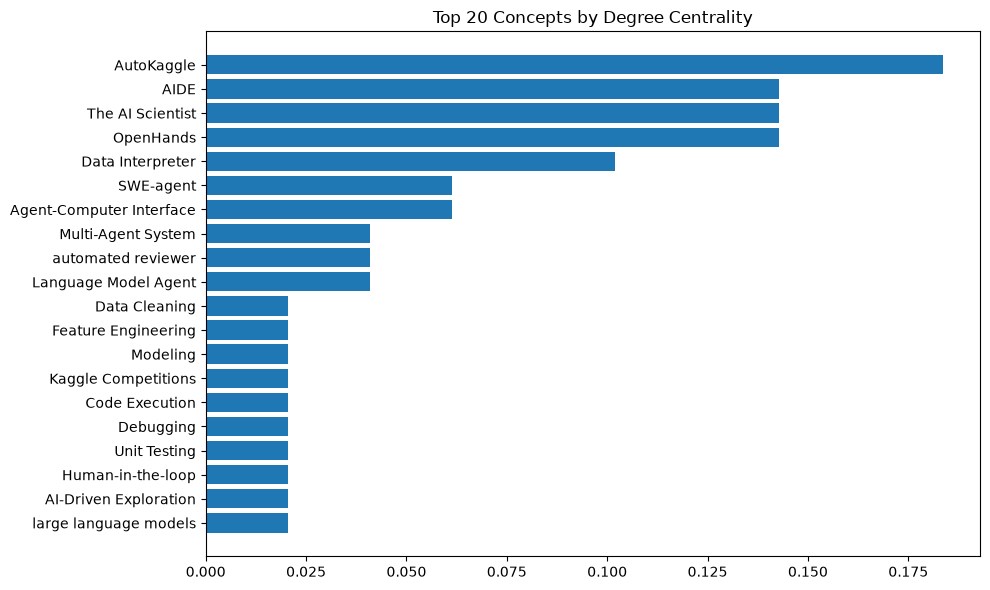

In [8]:
top20 = df.head(20)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    top20["Concept"],
    top20["Centrality"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 20 Concepts by Degree Centrality"
)

plt.tight_layout()

plt.show()

In [9]:
from collections import defaultdict

concept_to_papers = defaultdict(set)

graphs = {
    "AutoKaggle": g_autokaggle,
    "AIDE": g_aide,
    "DataInterpreter": g_data_interpreter,
    "AIScientist": g_ai_scientist,
    "SWEAgent": g_swe_agent,
    "OpenHands": g_openhands
}

for paper_name, graph in graphs.items():

    for node in graph.nodes():

        if node == paper_name:
            continue

        concept_to_papers[node].add(
            paper_name
        )

shared_concepts = []

for concept, papers in concept_to_papers.items():

    shared_concepts.append(
        (
            concept,
            len(papers),
            sorted(papers)
        )
    )

shared_concepts = sorted(
    shared_concepts,
    key=lambda x: x[1],
    reverse=True
)

shared_concepts[:20]

[('Multi-Agent System', 2, ['AutoKaggle', 'OpenHands']),
 ('Code Execution', 2, ['AutoKaggle', 'OpenHands']),
 ('Data Cleaning', 1, ['AutoKaggle']),
 ('Feature Engineering', 1, ['AutoKaggle']),
 ('Modeling', 1, ['AutoKaggle']),
 ('Kaggle Competitions', 1, ['AutoKaggle']),
 ('Debugging', 1, ['AutoKaggle']),
 ('Unit Testing', 1, ['AutoKaggle']),
 ('Human-in-the-loop', 1, ['AutoKaggle']),
 ('AI-Driven Exploration', 1, ['AIDE']),
 ('machine learning engineering agent', 1, ['AIDE']),
 ('large language models', 1, ['AIDE']),
 ('code optimization', 1, ['AIDE']),
 ('tree search', 1, ['AIDE']),
 ('Kaggle evaluations', 1, ['AIDE']),
 ('OpenAI MLE-Bench', 1, ['AIDE']),
 ('METRs RE-Bench', 1, ['AIDE']),
 ('Data Interpreter', 1, ['DataInterpreter']),
 ('LLM-based agent', 1, ['DataInterpreter']),
 ('Hierarchical Graph Modeling', 1, ['DataInterpreter'])]